In [2]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

(array([1., 0., 0., 0., 1., 0., 0., 0., 0., 1.]),
 array([ 779.3767469 ,  811.6531605 ,  843.9295741 ,  876.2059877 ,
         908.4824013 ,  940.75881491,  973.03522851, 1005.31164211,
        1037.58805571, 1069.86446931, 1102.14088291]),
 <BarContainer object of 10 artists>)

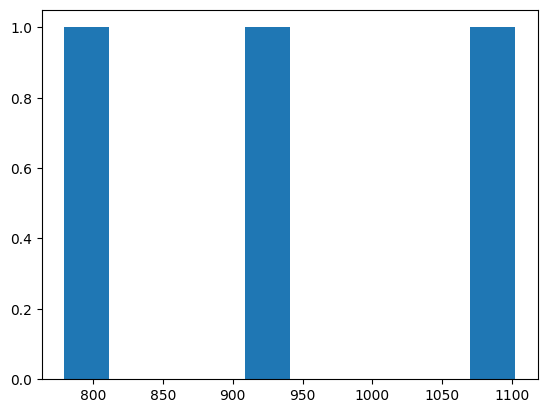

In [10]:
plt.hist(events.loc[[2, 17, 32], "luminosity_distance"])

In [8]:
events.loc[[2, 17, 32], "luminosity_distance"]

2     1102.140883
17     779.376747
32     935.664227
Name: luminosity_distance, dtype: float64

In [6]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
        try:
            posterior = np.load(f"em_posteriors/source_{j}/posterior.npz")

            quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]
        except:
            continue

    return quantiles

quantiles = quantile_list("log10_mej_dyn")

Text(0.5, 0, 'chirp mass quantiles')

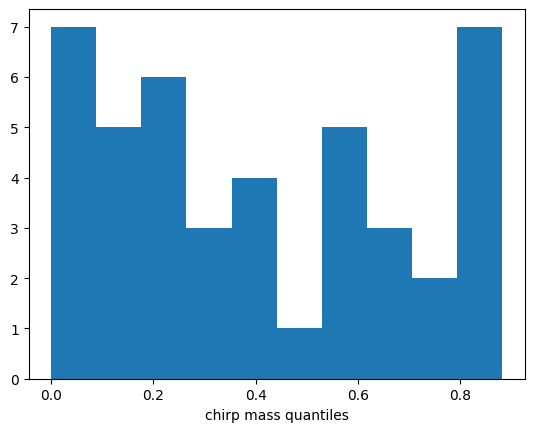

In [7]:

plt.hist(quantiles)
plt.xlabel("chirp mass quantiles")

In [8]:
inds = quantiles.argsort()
print(inds)

[ 2 17 31 32 10 27 30  9 37  5  0  7 35 13 16 22 41 28 39 18  3 33 23  4
  1 42 21 19 38  6 24 20 26  8 14 40 29 11 12 15 34 36 25]


In [11]:
quantiles_mass_ratio

array([0.        , 0.        , 0.        , 0.03829101, 0.95646289,
       0.46367347, 0.78897573, 0.63950672, 0.58148571, 0.06378803,
       0.88081617, 0.32045053, 0.5258923 , 0.12721755, 0.98222029,
       0.17039163, 0.60498138, 0.55898689, 0.79796163, 0.68098444,
       0.69137098, 0.95064019, 0.76118842, 0.8972722 , 0.47047244,
       0.50456781, 0.777956  , 0.02713851, 0.69865818, 0.47647849,
       0.35205733, 0.3365897 , 0.61488737, 0.15439932, 0.8544862 ,
       0.52871135, 0.53313953, 0.03837369, 0.75428034, 0.        ,
       0.846084  , 0.        , 0.87136465])

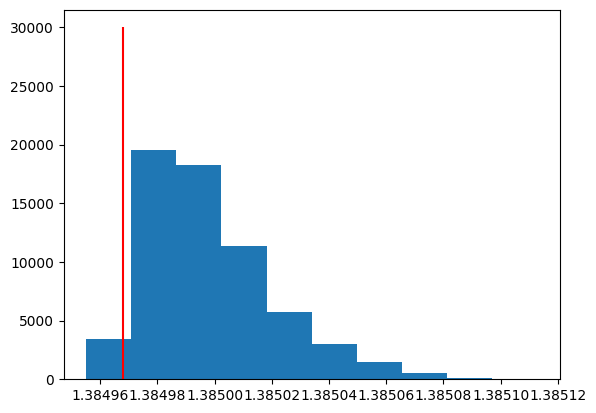

In [7]:
posterior = np.load("./gw_posteriors/source_42/posterior.npz")
plt.hist(posterior["chirp_mass"], density=True)
plt.vlines([events.loc[42, "chirp_mass"]], 0, 30_000, color="red")

In [19]:
from jesterTOV.inference.transforms import MultimessengerJesterTransform
from jesterTOV.utils import solar_mass_in_meter

from nmma.core.conversion import BNSEjectaFitting

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
mass_1 = events.loc[22, "mass_1_source"]
mass_2 = events.loc[22, "mass_2_source"]
radius_1 = events.loc[22, "radius_1"]
radius_2 = events.loc[22, "radius_2"]
compactness_1 = mass_1 / radius_1 * solar_mass_in_meter * 1e-3
compactness_2 = mass_2 / radius_2 * solar_mass_in_meter * 1e-3

log10_mej_dyn = np.log10(MultimessengerJesterTransform.dynamic_mass_fitting(mass_1, mass_2, compactness_1, compactness_2))

In [23]:
print(log10_mej_dyn, events.loc[22, "log10_mej_dyn"])

-2.235712866528109 -2.235648111224239


In [31]:
import jax

jax.random.uniform(jax.random.key(57191), shape=(10,), minval=1.32, maxval=1.2)

Array([1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32],      dtype=float64)

In [22]:
events["mass_ratio"].min()

np.float64(0.7258205335293277)